# **CODSOFT INTERNSHIP TASK 3**

# IRIS FLOWER CLASSIFICATION

# *Importing the needed Libraries*

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import scipy as sp 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler , MinMaxScaler , LabelEncoder , Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score ,precision_score,f1_score,confusion_matrix,classification_report,auc,roc_curve
from sklearn.datasets import load_iris 

In [3]:
data = load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
data = pd.DataFrame(data.data , columns = data.feature_names)

In [5]:
data["target"] = load_iris().target

In [6]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
data.shape

(150, 5)

In [8]:
data.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int32
dtype: object

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [10]:
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


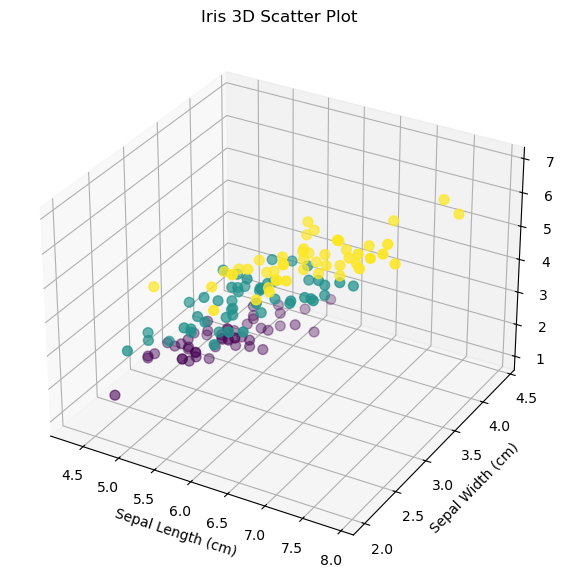

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data['sepal length (cm)'], data['sepal width (cm)'],
          data['petal length (cm)'], c=data['target'],
          cmap='viridis', s=50)

ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_zlabel('Petal Length (cm)')
ax.set_title('Iris 3D Scatter Plot')

plt.show()

In [12]:
X = data.drop(columns = ["target", "sepal length (cm)" ,"sepal width (cm)"])
Y = data["target"]

In [13]:
X_train , X_test , Y_train , Y_test = train_test_split( X , Y ,
                         test_size = 0.2 , random_state = 42)

In [14]:
X_train.shape

(120, 2)

In [15]:
Y_train.shape

(120,)

In [16]:
X_test.shape

(30, 2)

In [17]:
Y_test.shape

(30,)

# **Standardization**

In [18]:
scaler = StandardScaler ()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Logistic Regression Model**

In [19]:
model = LogisticRegression()

In [20]:
history = model.fit(X_train , Y_train)

In [21]:
# Predicting the model
Y_pred = model.predict(X_test)

In [22]:
# Model Evaluation 
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score (Y_test , Y_pred , average = "weighted")
f1 = f1_score(Y_test , Y_pred , average = "weighted")

print(f"Accuracy : {accuracy}")
print(f"Precesion : {precision}")
print(f"F1_score : {f1}")

Accuracy : 1.0
Precesion : 1.0
F1_score : 1.0


# **Confusion Matric**

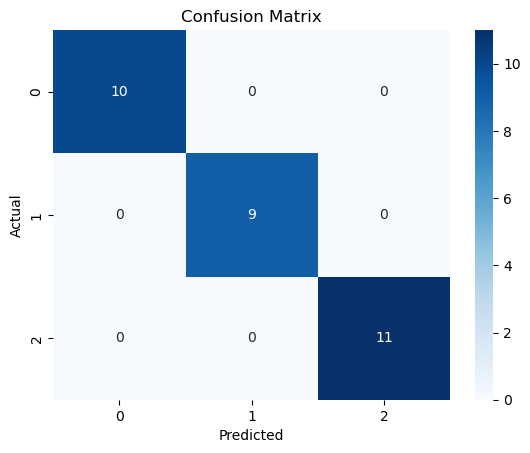

In [23]:
# Determine the performance of a classification model by analyzing its predictions compared to actual outcomes.
conf_matrix = confusion_matrix(Y_test, Y_pred)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
          xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

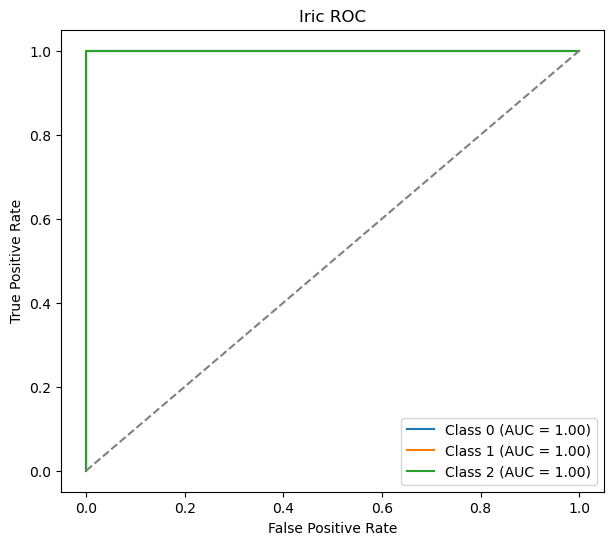

In [24]:
# Calculation of the ROC curve for each class.
y_scores = model.predict_proba(X_test)
fpr = {}
tpr = {}
roc_auc = {}

# Convert Y_test to one-hot encoding
Y_test_one_hot = pd.get_dummies(Y_test)

for i in range(len(model.classes_)):
	fpr[i], tpr[i], _ = roc_curve(Y_test_one_hot.iloc[:, i], y_scores[:, i])
	roc_auc[i] = auc(fpr[i], tpr[i])

# Displaying the ROC curve for each class
plt.figure(figsize=(7, 6))
for i in range(len(model.classes_)):
	plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Iric ROC')
plt.legend()
plt.show()

# **Model Validation**

In [25]:
from sklearn.model_selection import cross_val_score, KFold

# Configuration of KFold.
kf = KFold(n_splits = 9 , shuffle = True, random_state = 42)

# Calculation of cross-validation scores
cv_scores = cross_val_score(model , X, Y ,
                         cv = kf, scoring = 'accuracy')

# Displaying the results.
print(f"Scores de validation croisee : {cv_scores}")
print(f"Score moyen : {cv_scores.mean():.2f}") 

Scores de validation croisee : [1.         1.         0.94117647 1.         0.94117647 0.82352941
 1.         1.         0.9375    ]
Score moyen : 0.96


In [26]:
# Prediction on test data
y_pred = model.predict(X_test)

# Model accuracy
accuracy = accuracy_score(Y_test , y_pred)
print(f"Accuracy de test est : {accuracy:.2f}")

# Prediction on training data.
y_pred_1 = model.predict(X_train)
acc = accuracy_score( Y_train , y_pred_1)
print(f"Accuracy de train est : {acc:.2f}")

Accuracy de test est : 1.00
Accuracy de train est : 0.94


# **KNN Model**

In [27]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model with K=5.
knn = KNeighborsClassifier(n_neighbors= 5)

# Train the model.
knn.fit(X_train, Y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy du modèle KNN : {accuracy:.2f}")

print("Matrice de Confusion :\n", confusion_matrix(Y_test, y_pred))
print("Rapport de Classification :\n", classification_report(Y_test, y_pred))

Accuracy du modèle KNN : 1.00
Matrice de Confusion :
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Rapport de Classification :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [28]:
from sklearn.model_selection import cross_val_score, KFold

# Configuration of KFold.
kf = KFold(n_splits = 7 , shuffle = True, random_state = 42)

# Calculation of cross-validation scores
cv_scores = cross_val_score(model , X, Y ,
                         cv = kf, scoring = 'accuracy')

# Displaying the results  
print(f"Scores de validation croisee : {cv_scores}")
print(f"Score moyen : {cv_scores.mean():.2f}") 

Scores de validation croisee : [1.         1.         0.95454545 0.95238095 0.85714286 1.
 0.95238095]
Score moyen : 0.96


In [29]:
# Prediction on test data.
y_pred_K = knn.predict(X_test)

# Accuracy du modèle
accuracy = accuracy_score(Y_test , y_pred)
print(f"Accuracy de test est : {accuracy:.2f}")

# Prediction on training data.
y_pred_K = knn.predict(X_train)
acc = accuracy_score( Y_train , y_pred_1)
print(f"Accuracy de train est : {acc:.2f}")

Accuracy de test est : 1.00
Accuracy de train est : 0.94


# **Random Forest Classifier**

In [30]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [31]:
x = data.drop("target", axis=1)

y = data["target"]

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [32]:
clf.fit(x_train, y_train);

In [33]:
clf.score(x_train, y_train)

1.0

In [34]:
clf.score(x_test, y_test)

0.9666666666666667

In [35]:
y_preds = clf.predict(x_test)
y_preds

array([2, 1, 1, 1, 2, 2, 2, 1, 1, 0, 0, 0, 2, 0, 0, 1, 1, 1, 1, 1, 2, 0,
       2, 1, 1, 2, 0, 2, 1, 0])

In [36]:
np.array(y_test)

array([2, 1, 1, 1, 2, 2, 2, 1, 1, 0, 0, 0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       2, 1, 1, 2, 0, 2, 1, 0])

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.93      0.96        14
           2       0.89      1.00      0.94         8

    accuracy                           0.97        30
   macro avg       0.96      0.98      0.97        30
weighted avg       0.97      0.97      0.97        30



* From the classification report provided above, we can see how each (precision, recall, f1-score) scores ranges
* F1 - score perform more than the rest of the reports

In [38]:
confusion_matrix(y_test, y_preds)

array([[ 8,  0,  0],
       [ 0, 13,  1],
       [ 0,  0,  8]], dtype=int64)

In [39]:
accuracy_score(y_preds, y_test)

0.9666666666666667

In [40]:
# improving our model
np.random.seed(43)
for i in range (10, 110, 10):
    print(f"Trying model with {i} estimators")
    clf=RandomForestClassifier(n_estimators=i).fit(x_train, y_train)
    print(f"The accuracy of the model:{clf.score(x_test, y_test)*100:2f}%")
    print("")

Trying model with 10 estimators
The accuracy of the model:96.666667%

Trying model with 20 estimators
The accuracy of the model:96.666667%

Trying model with 30 estimators
The accuracy of the model:96.666667%

Trying model with 40 estimators
The accuracy of the model:96.666667%

Trying model with 50 estimators
The accuracy of the model:96.666667%

Trying model with 60 estimators
The accuracy of the model:96.666667%

Trying model with 70 estimators
The accuracy of the model:96.666667%

Trying model with 80 estimators
The accuracy of the model:96.666667%

Trying model with 90 estimators
The accuracy of the model:96.666667%

Trying model with 100 estimators
The accuracy of the model:96.666667%

